Alumno: Carlos Alejandro Pérez Casares

TFG Predecir diabetes tipo 2

In [1]:
import pandas as pd
import xport

# Cargar datos BRFSS 2014
df = pd.read_csv("LLCP2014.csv")


/home/alex/miniconda3/envs/jupyter-env/lib/python3.9/site-packages/xport/__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tmp/ipykernel_16368/138320614.py:5: DtypeWarning: Columns (120) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("LLCP2014.csv")


In [2]:
print("Resumen de tipos de datos")
print(df.dtypes.value_counts())

Resumen de tipos de datos
float64    274
int64        4
object       1
dtype: int64


**Descartado de columnas variables) que se refieren a fechas y horas**

****Etapa 1.Dataset limpio****

In [5]:
df1 = df.drop(columns=["_STATE", "FMONTH", "IDATE", "IMONTH", "IDAY", "IYEAR", "DISPCODE", "SEQNO", "_PSU"])

In [6]:
print("Resumen de tipos de datos")
print(df1.dtypes.value_counts())

Resumen de tipos de datos
float64    269
object       1
dtype: int64


***gráfica de barras con el recuento de frecuencias de la columna "DIABETE3"***

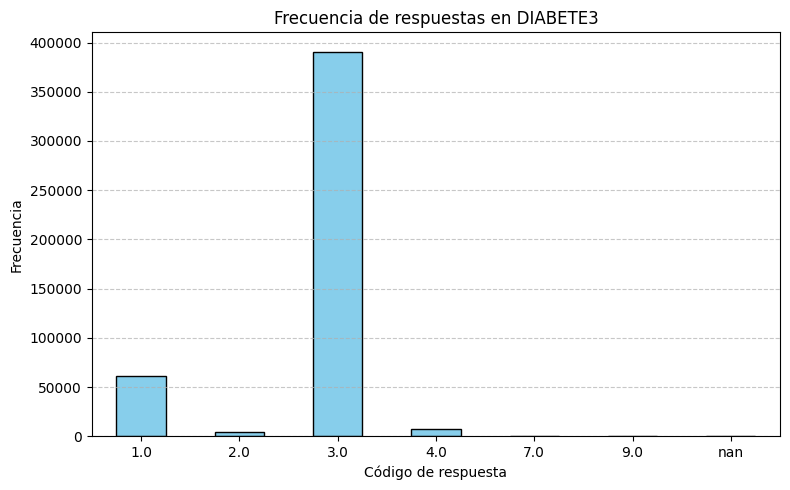

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame cargado como df1
# Recuento de frecuencias
counts = df1["DIABETE3"].value_counts(dropna=False).sort_index()

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Frecuencia de respuestas en DIABETE3")
plt.xlabel("Código de respuesta")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


La columna "DIABETE3" tiene varias categorías, pero solo queremos el valor 1: Sí diabetes y 3:No diabetes

In [6]:
df1 = df1[df1["DIABETE3"].isin([1, 3])]


In [8]:
df2 = df1

Filas del juego de datos para respondentes menores de 30 años (categorías 1 y 2) los descartamos. Menores de 30 años tendrían diabetes de tipo 1.

In [9]:
print("Resumen de tipos de datos")
print(df2.dtypes.value_counts())

Resumen de tipos de datos
float64    269
object       1
dtype: int64


In [10]:
df3 = df2.copy()

In [127]:
print("Resumen de tipos de datos")
print(df3.dtypes.value_counts())

Resumen de tipos de datos
float64    269
object       1
dtype: int64


In [11]:
df3.shape[1]

270

In [12]:
# Mostrar columnas de tipo object
object_cols = df3.select_dtypes(include='object').columns.tolist()
print("Columnas tipo object:", object_cols)


Columnas tipo object: ['DLYOTHER']


In [13]:
df3 = df3.drop('DLYOTHER', axis=1) # variable descartada del dataset

In [14]:
obj_cols = df3.select_dtypes(include=['object']).columns.tolist()
print(obj_cols)

[]


In [15]:
df3.shape[1] # número de variables en datafrane df3

269

In [16]:
print("Resumen de tipos de datos")
print(df3.dtypes.value_counts())

Resumen de tipos de datos
float64    269
dtype: int64


In [17]:
# Variables que no aportan nada
cols_to_drop = ['RCSBRAC1', 'RCSRACE1', 'RCHISLA1', 'RCSBIRTH']
existing = [c for c in cols_to_drop if c in df3.columns]
df3 = df3.drop(columns=existing)


In [18]:
df3.to_csv("df3.csv")

In [19]:
import pandas as pd
df = pd.read_csv('df3.csv')
df = df.drop_duplicates()

In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [21]:
duplicates = pd.merge(train_df, test_df, how='inner')
print(f'Duplicados entre train y test: {len(duplicates)}')


Duplicados entre train y test: 0


In [22]:
df.to_csv("df3.csv")

In [23]:
print(df.dtypes.value_counts())

float64    265
int64        1
dtype: int64


### Codificar: 
3.0 -> 0 - no diabetes
1.0 -> 1 - si diabetes

In [24]:
df = pd.read_csv("df3.csv")

*Descartar el resto de filas de DIABETE3 que no contengan 3.0 y 1.0 en el dataframe df.*

In [25]:
df["DIABETE3"].isna().sum()


2

In [26]:
df["DIABETE3"].value_counts(dropna=False)


3.0    390827
1.0     61118
4.0      7668
2.0      4207
7.0       551
9.0       291
NaN         2
Name: DIABETE3, dtype: int64

- Mapeo: clase 0, no; clase 1, sí.

In [27]:
df = df[df["DIABETE3"].isin([1.0, 3.0])]
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0}).astype(int)

- Dataset muy desiquilbrado respecto a la variable objetivo DIABETE3.

In [28]:
df["DIABETE3"].value_counts(dropna=False) # 


0    390827
1     61118
Name: DIABETE3, dtype: int64

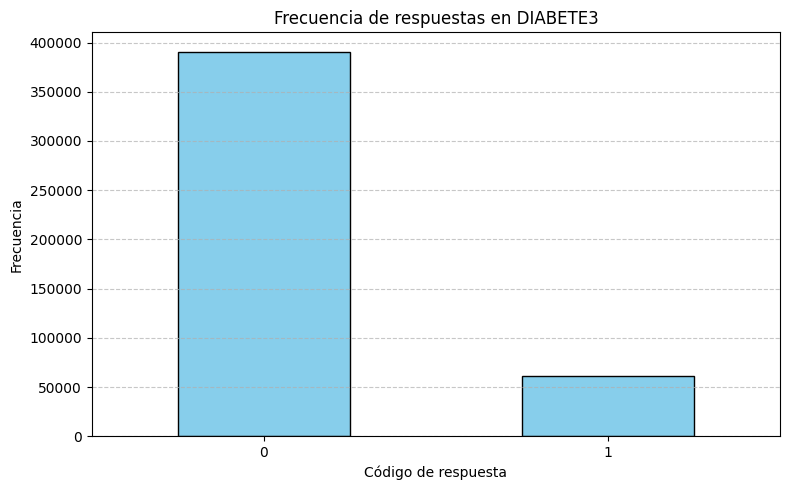

In [29]:
# DataFrame cargado como df1
# Recuento de frecuencias
import matplotlib.pyplot as plt

counts = df["DIABETE3"].value_counts(dropna=False).sort_index()

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Frecuencia de respuestas en DIABETE3")
plt.xlabel("Código de respuesta")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
df.to_csv("df3.csv")

## Split, imputación de valores faltantes, codificación de categorías a enteros, escalado (media y desviación estándar)

**Codificar columnas categóricas**
Fuente: GitHub (2020) Multi Column Label Encoder. 
https://gist.github.com/Saphirox/4204870c6e9c5fa28c7ac441fe1424ac [consultado 17/10/2025] Código adaptado.

Fuente: Machine Learning with PyTorch and Scikit-Learn.(2022)
https://learning.oreilly.com/library/view/machine-learning-with/9781801819312/Text/Chapter_4.xhtml#_idParaDest-82 [consultado 17/10/2025]
Código adaptado.

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# -----------------------------
# 1. Cargar dataset
# -----------------------------
df = pd.read_csv("df3.csv")

TARGET = "DIABETE3"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

# -----------------------------
# 2. Split train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 3. Detectar columnas categóricas y numéricas
#    (criterio: cardinalidad baja → categórica)
# -----------------------------
CARDINALITY_THRESHOLD = 10
nunique = X_train.nunique(dropna=True)

cat_cols = nunique[nunique <= CARDINALITY_THRESHOLD].index.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

# -----------------------------
# 4. Imputación (fit en train)
# -----------------------------
imp_cat = SimpleImputer(strategy="most_frequent")
imp_num = SimpleImputer(strategy="mean")

X_train_cat = imp_cat.fit_transform(X_train[cat_cols])
X_test_cat  = imp_cat.transform(X_test[cat_cols])

X_train_num = imp_num.fit_transform(X_train[num_cols])
X_test_num  = imp_num.transform(X_test[num_cols])

# -----------------------------
# 5. Codificación (fit en train)
# -----------------------------
# convierte categorías en números enteros
enc = OrdinalEncoder( # reemplaza los valores enteros originales por nuevos códigos enteros
    dtype=int,
    handle_unknown="use_encoded_value",
    unknown_value=-1 # para valores desconocidos se pode -1  en vez de fallar
)

X_train_cat_enc = enc.fit_transform(X_train_cat)
X_test_cat_enc  = enc.transform(X_test_cat)

# -----------------------------
# 6. Escalado (fit en train)
# -----------------------------
# convierte las variables a una escala con: media = 0, desviación estándar = 1
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

# -----------------------------
# 7. Reconstruir matrices finales
# -----------------------------
import numpy as np

X_train_final = np.hstack([X_train_num_scaled, X_train_cat_enc])
X_test_final  = np.hstack([X_test_num_scaled,  X_test_cat_enc])

print("Shape train final:", X_train_final.shape)
print("Shape test final:", X_test_final.shape)

Categóricas: ['CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'LADULT', 'GENHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'EXERANY2', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'LASTDEN3', 'RMVTETH3', 'VETERAN3', 'MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME2', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'INTERNET', 'RENTHOM1', 'SEX', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'FLUSHOT6', 'PNEUVAC3', 'SHINGLE2', 'SEATBELT', 'HADMAM', 'HOWLONG', 'PROFEXAM', 'LENGEXAM', 'HADPAP2', 'LASTPAP2', 'HADHYST2', 'PCPSAAD2', 'PCPSADI1', 'PCPSARE1', 'PSATEST1', 'PSATIME', 'PCPSARS1', 'BLDSTOOL', 'LSTBLDS3', 'HADSIGM3', 'HADSGCO1', 'LASTSIG3', 'HIVTST6', 'PDIABTST', 'PREDIAB1', 'INSULIN', 'EYEEXAM', 'DIABEYE', 'DIABEDU', 'MEDICARE', 'HLTHCVR1', 'DELAYMED', 'NOCOV121', 'LSTCOVRG', 'MEDSCOST', 'CARERCVD', 'MEDBILL1', 

In [ ]:
## Crear CSV a partir de `X_train_final` y `X_test_final`

Referencia: 
- Microsoft.(2025)Microsoft Copilot.(versión 1 de noviembre)[Large language model].  https://copilot.microsoft.com/chats/

In [32]:
import pandas as pd
import numpy as np

# --- Reconstruir DataFrames con nombres de columnas ---
# num_cols y cat_cols vienen del pipeline previo
all_cols = num_cols + cat_cols

df_train_final = pd.DataFrame(X_train_final, columns=all_cols)
df_test_final  = pd.DataFrame(X_test_final,  columns=all_cols)

# Añadir la variable objetivo
df_train_final["DIABETE3"] = y_train.values
df_test_final["DIABETE3"]  = y_test.values

# --- Exportar a CSV ---
df_train_final.to_csv("train_prepared.csv", index=False)
df_test_final.to_csv("test_prepared.csv", index=False)

print("Archivos generados: train_prepared.csv y test_prepared.csv")

Archivos generados: train_prepared.csv y test_prepared.csv


In [33]:
print(df.dtypes.value_counts())

float64    264
int64        4
dtype: int64


## Aplicando RFE (Recursive Features Elimination)

In [1]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# ============================================================
# 1. Cargar datasets limpios
# ============================================================
df_train = pd.read_csv("train_prepared.csv")
df_test  = pd.read_csv("test_prepared.csv")

TARGET = "DIABETE3"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET].astype(int)

# ============================================================
# 2. Modelo base para RFE (Regresión Logística)
# ============================================================
model = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    
)



# ============================================================
# 3. Aplicar RFE para seleccionar 30 variables
# ============================================================
selector = RFE(
    estimator=model,
    n_features_to_select=30,
    step=5
)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_].tolist()

print("Variables seleccionadas (30):")
for col in selected_features:
    print(col)

# ============================================================
# 4. Reducir train y test a las 30 variables
# ============================================================
df_train_rfe = df_train[selected_features + [TARGET]]
df_test_rfe  = df_test[selected_features + [TARGET]]

# ============================================================
# 5. Guardar datasets reducidos
# ============================================================
df_train_rfe.to_csv("train_rfe.csv", index=False)
df_test_rfe.to_csv("test_rfe.csv", index=False)

print("\nArchivos generados: train_rfe.csv y test_rfe.csv")

Variables seleccionadas (30):
Unnamed: 0.1
Unnamed: 0
_STSTR
WTKG3
CTELENUM
GENHLTH
CVDINFR4
CHCKIDNY
PNEUVAC3
PDIABTST
PREDIAB1
INSULIN
EYEEXAM
DIABEYE
DIABEDU
MEDSCOST
ASBIDRNK
ASBIRDUC
WTCHSALT
CSRVSUM
CSRVPAIN
SCNTMEL1
SCNTPAID
SCNTLPAD
SCNTVOT1
CTELNUM1
_RFHLTH
_RACEG21
_AGE_G
_BMI5CAT

Archivos generados: train_rfe.csv y test_rfe.csv


In [2]:
df = pd.read_csv("train_rfe.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.to_csv("train_rfe.csv", index=False)

In [3]:
df = pd.read_csv("test_rfe.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.to_csv("test_rfe.csv", index=False)

In [ ]:
'_STSTR','WTKG3','CTELENUM','GENHLTH','CVDINFR4','CHCKIDNY','PNEUVAC3','PDIABTST','PREDIAB1','INSULIN','EYEEXAM','DIABEYE','DIABEDU','MEDSCOST','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN','SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'

In [ ]:
Variables que provocan data leakage (deben eliminarse). Estas variables revelan directamente o indirectamente el estado de diabetes, o son consecuencias del diagnóstico, por lo que no pueden usarse para predecir diabetes:
"PDIABTST","PREDIAB1","INSULIN","EYEEXAM","DIABEYE","DIABEDU",
    "MEDSCOST","CHCKIDNY","PNEUVAC3","CVDINFR4","GENHLTH"

Cada barra es una variable.

La longitud de la barra es el valor absoluto del coeficiente del modelo.

Cuanto mayor sea el coeficiente, más contribuye esa variable a la predicción de diabetes.

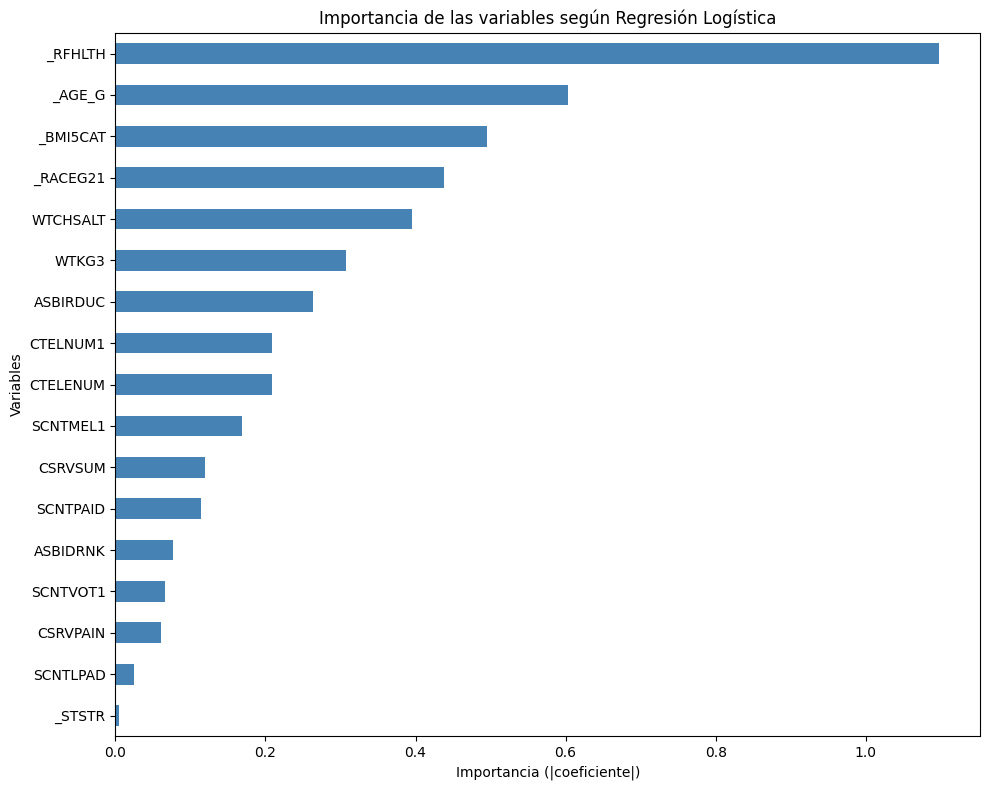

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# -----------------------------------------
# 1. VARIABLES SELECCIONADAS
# -----------------------------------------
selected_features = [
    '_STSTR','WTKG3','CTELENUM','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'
]

TARGET = "DIABETE3"

# -----------------------------------------
# 2. CARGAR DATASET
# -----------------------------------------
df = pd.read_csv("train_rfe.csv")

# -----------------------------------------
# 3. PREPARAR MATRICES
# -----------------------------------------
X = df[selected_features]
y = df[TARGET].astype(int)

# -----------------------------------------
# 4. ENTRENAR MODELO
# -----------------------------------------
model = LogisticRegression(max_iter=2000, solver="liblinear")
model.fit(X, y)

# -----------------------------------------
# 5. IMPORTANCIA DE VARIABLES
# -----------------------------------------
coef = np.abs(model.coef_[0])
importance = pd.Series(coef, index=selected_features).sort_values()

# -----------------------------------------
# 6. GRAFICAR
# -----------------------------------------
plt.figure(figsize=(10, 8))
importance.plot(kind="barh", color="steelblue")

plt.xlabel("Importancia (|coeficiente|)")
plt.ylabel("Variables")
plt.title("Importancia de las variables según Regresión Logística")
plt.tight_layout()
plt.show()


Variables con riesgo de fuga deben ser descartadas del modelo.

In [4]:
import pandas as pd

cols_to_remove = [
    "PDIABTST","PREDIAB1","INSULIN","EYEEXAM","DIABEYE","DIABEDU",
    "MEDSCOST","CHCKIDNY","PNEUVAC3","CVDINFR4","GENHLTH"
]

# Limpiar train_rfe.csv
df_train = pd.read_csv("train_rfe.csv")
df_train = df_train.drop(columns=cols_to_remove, errors="ignore")
df_train.to_csv("train_rfe.csv", index=False)

# Limpiar test_rfe.csv
df_test = pd.read_csv("test_rfe.csv")
df_test = df_test.drop(columns=cols_to_remove, errors="ignore")
df_test.to_csv("test_rfe.csv", index=False)

print("Variables de fuga eliminadas correctamente.")


Variables de fuga eliminadas correctamente.


In [ ]:
Variables seguras, sin fuga de datos:

In [ ]:
'_STSTR','WTKG3','CTELENUM','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'

## Aplicar SMOTENC

In [45]:
!pip install imbalanced-learn

In [5]:
import pandas as pd

df = pd.read_csv("train_rfe.csv")
print("SEX" in df.columns)
print(df.columns.tolist())


False
['_STSTR', 'WTKG3', 'CTELENUM', 'ASBIDRNK', 'ASBIRDUC', 'WTCHSALT', 'CSRVSUM', 'CSRVPAIN', 'SCNTMEL1', 'SCNTPAID', 'SCNTLPAD', 'SCNTVOT1', 'CTELNUM1', '_RFHLTH', '_RACEG21', '_AGE_G', '_BMI5CAT', 'DIABETE3']


In [6]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTENC
from collections import Counter

# -----------------------------------------
# 1. CONFIGURACIÓN
# -----------------------------------------
DATA_PATH = "train_rfe.csv"
OUTPUT_PATH = "train_smote.csv"

FEATURES = [
   '_STSTR','CTELENUM','WTKG3','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
   'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'
]

TARGET = "DIABETE3"

cat_cols = [
   '_STSTR','CTELENUM','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
   'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'
]

num_cols = ['WTKG3']

# -----------------------------------------
# 2. CARGAR
# -----------------------------------------
df = pd.read_csv(DATA_PATH)

# -----------------------------------------
# 3. LIMPIEZA
# -----------------------------------------
df = df.replace([888.0, 88.0, 77.0, 99.0], np.nan)

# -----------------------------------------
# 4. FILTRAR VARIABLES
# -----------------------------------------
df_sel = df[FEATURES + [TARGET]].copy()

# -----------------------------------------
# 5. IMPUTACIÓN
# -----------------------------------------
for col in cat_cols:
    df_sel[col] = df_sel[col].fillna(df_sel[col].mode()[0])

for col in num_cols:
    df_sel[col] = df_sel[col].fillna(df_sel[col].median())

df_sel = df_sel.dropna(subset=[TARGET])

# -----------------------------------------
# 6. PREPARAR SMOTENC (sin SEX)
# -----------------------------------------
cat_feature_indices = [df_sel[FEATURES].columns.get_loc(c) for c in cat_cols]

smote_nc = SMOTENC(
    categorical_features=cat_feature_indices,
    random_state=42
)

# -----------------------------------------
# 7. APLICAR SMOTENC A TODO EL DATASET
# -----------------------------------------
X = df_sel[FEATURES]
y = df_sel[TARGET].astype(int)

X_res, y_res = smote_nc.fit_resample(X, y)

print("Distribución original:", Counter(y))
print("Distribución balanceada:", Counter(y_res))

# -----------------------------------------
# 8. GUARDAR
# -----------------------------------------
df_balanced = pd.DataFrame(X_res, columns=FEATURES)
df_balanced[TARGET] = y_res

df_balanced.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset balanceado guardado en: {OUTPUT_PATH}")


Distribución original: Counter({0: 312662, 1: 48894})
Distribución balanceada: Counter({0: 312662, 1: 312662})
Dataset balanceado guardado en: train_smote.csv


### Gráficas antes y después del balanceado con SMOTENC


# ETAPA. Mitigación de sesgos con AIF360

AI Fairness 360 Development Team. (n.d.). AI Fairness 360 documentation (aif360 0.6.1). Read the Docs. [Consultado 7 nov 2025] https://aif360.readthedocs.io/en/stable/index.html

   

- ¿Sesgo por edad?

In [8]:
from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset


# crear columna (mediana) y la binaria
threshold = df['_AGE_G'].median() # '_AGEG5YR' está escalada como float
df['age_group'] = df['_AGE_G'].apply(lambda x: 'mayores' if x >= threshold else 'jóvenes')
df['age_group_bin'] = df['age_group'].map({'jóvenes': 0, 'mayores': 1})

# eliminar la columna string para evitar el error de conversión
df = df.drop(columns=['age_group'])



dataset_bin = StandardDataset(df,
                             label_name='DIABETE3',
                             favorable_classes=[1],
                             protected_attribute_names=['age_group_bin'],
                             privileged_classes=[[1]],
                             features_to_drop=[])
# privileged_groups=[{'age_group': 'mayores'}
metric_orig = BinaryLabelDatasetMetric(dataset_bin,
                                  privileged_groups=[{'age_group_bin': 1}],
                                  unprivileged_groups=[{'age_group_bin': 0}])
# Métrica antes
print("Disparate impact (antes):", metric_orig.disparate_impact())

# Reweighing (con age_group)
RW = Reweighing(unprivileged_groups=[{'age_group_bin': 0}],
                privileged_groups=[{'age_group_bin': 1}])
dataset_transf = RW.fit_transform(dataset_bin)

# Métrica después
metric_transf = BinaryLabelDatasetMetric(dataset_transf,
                                         privileged_groups=[{'age_group_bin': 1}],
                                         unprivileged_groups=[{'age_group_bin': 0}])
print("Disparate impact (después):", metric_transf.disparate_impact())

Disparate impact (antes): 0.30762025047157454
Disparate impact (después): 1.0


- Tu modelo es claramente injusto contra el grupo no privilegiado (jóvenes).
- Todas las métricas apuntan en la misma dirección: el modelo favorece a los mayores.

Script para mitigar sesgo por edad usando AIF360 Reweighing.
Incluye:

   - creación del atributo protegido

   - binarización por mediana

   - construcción del StandardDataset

   - cálculo de métricas antes y después

   - mitigación con Reweighing

   - impresión clara de resultados

In [9]:
import pandas as pd
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

# ============================================================
# 1. Cargar dataset balanceado
# ============================================================
df = pd.read_csv("train_smote.csv")

df['DIABETE3'] = df['DIABETE3'].astype(int)
df['_AGE_G'] = df['_AGE_G'].astype(float)

# ============================================================
# 2. Crear variable protegida age_group_bin
# ============================================================
threshold = df['_AGE_G'].median()

df['age_group'] = df['_AGE_G'].apply(
    lambda x: 'mayores' if x >= threshold else 'jóvenes'
)

df['age_group_bin'] = df['age_group'].map({'jóvenes': 0, 'mayores': 1}).astype(int)
df = df.drop(columns=['age_group'])

# ============================================================
# 3. Crear StandardDataset
# ============================================================
dataset = StandardDataset(
    df,
    label_name='DIABETE3',
    favorable_classes=[1],
    protected_attribute_names=['age_group_bin'],
    privileged_classes=[[1]],
    features_to_drop=[]
)

# ============================================================
# 4. Métricas ANTES de mitigar
# ============================================================
metric_dataset_orig = BinaryLabelDatasetMetric(
    dataset,
    privileged_groups=[{'age_group_bin': 1}],
    unprivileged_groups=[{'age_group_bin': 0}]
)

print("=== MÉTRICAS ANTES ===")
print("Disparate Impact:", metric_dataset_orig.disparate_impact())

# Para EO y AOD necesitamos ClassificationMetric
metric_class_orig = ClassificationMetric(
    dataset, dataset,
    privileged_groups=[{'age_group_bin': 1}],
    unprivileged_groups=[{'age_group_bin': 0}]
)

print("Equal Opportunity Difference:", metric_class_orig.equal_opportunity_difference())
print("Average Odds Difference:", metric_class_orig.average_odds_difference())

# ============================================================
# 5. Aplicar Reweighing
# ============================================================
RW = Reweighing(
    unprivileged_groups=[{'age_group_bin': 0}],
    privileged_groups=[{'age_group_bin': 1}]
)

dataset_transf = RW.fit_transform(dataset)

# ============================================================
# 6. Métricas DESPUÉS de mitigar
# ============================================================
metric_dataset_transf = BinaryLabelDatasetMetric(
    dataset_transf,
    privileged_groups=[{'age_group_bin': 1}],
    unprivileged_groups=[{'age_group_bin': 0}]
)

print("\n=== MÉTRICAS DESPUÉS ===")
print("Disparate Impact:", metric_dataset_transf.disparate_impact())

metric_class_transf = ClassificationMetric(
    dataset_transf, dataset_transf,
    privileged_groups=[{'age_group_bin': 1}],
    unprivileged_groups=[{'age_group_bin': 0}]
)

print("Equal Opportunity Difference:", metric_class_transf.equal_opportunity_difference())
print("Average Odds Difference:", metric_class_transf.average_odds_difference())


=== MÉTRICAS ANTES ===
Disparate Impact: 0.470121581885706
Equal Opportunity Difference: 0.0
Average Odds Difference: 0.0

=== MÉTRICAS DESPUÉS ===
Disparate Impact: 1.0000000000000004
Equal Opportunity Difference: 0.0
Average Odds Difference: 0.0


- El Disparate Impact mide:
Interpretación:

    1.0 → trato igual

    0.8–1.25 → aceptable

    < 0.8 → discriminación

    ≈ 0.40 → discriminación severa

Antes de mitigar, los jóvenes recibían solo el 39.5% de las predicciones positivas que recibían los mayores.  
Esto indica un sesgo estructural fuerte contra el grupo joven.

- La diferencia en TPR (sensibilidad) entre grupos:


Valor = 0.0 significa:

El modelo detecta casos reales de diabetes igual de bien en ambos grupos.

No hay sesgo en sensibilidad.

- Promedia diferencias en:

    TPR (verdaderos positivos)

    FPR (falsos positivos)

Valor = 0.0 significa:

El modelo comete errores al mismo ritmo en ambos grupos.

No hay sesgo en rendimiento.

nterpretación final

Tu pipeline logró lo ideal:
✔ Antes:

    Sesgo fuerte en distribución (DI ≈ 0.47)

    Sin sesgo en rendimiento (EO = 0, AOD = 0)

✔ Después:

    Sesgo de distribución corregido (DI ≈ 1.0)

    Rendimiento sigue equilibrado (EO = 0, AOD = 0)

- Conclusión:

La mitigación por edad ha sido exitosa, estable y sin sobrecorrección.


Después de aplicar AIF360 Reweighing, lo que se tiene NO es un nuevo DataFrame con valores modificados, sino un BinaryLabelDataset con pesos ajustados (instance_weights).
AIF360 no cambia las features ni las etiquetas: solo cambia los pesos que deben usarse al entrenar el modelo.

In [17]:
import pandas as pd

# Convertir dataset AIF360 → DataFrame
df_mitigated = pd.DataFrame(
    dataset_transf.features,
    columns=dataset_transf.feature_names
)

# Añadir la etiqueta
df_mitigated['DIABETE3'] = dataset_transf.labels.ravel()

# Añadir los pesos corregidos por Reweighing
df_mitigated['instance_weight'] = dataset_transf.instance_weights

# Guardar CSV final
df_mitigated.to_csv("train_aif360_reweighing.csv", index=False)

print("Dataset mitigado guardado como train_aif360_reweighing.csv")


Dataset mitigado guardado como train_aif360_reweighing.csv


## Entrenar algoritmo de  aprendizaje automático Regresión Logística

# Regresión Logística

Fuente: Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition.
https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/ch04.html#id86
[Consultado 30/10/2025] Código adaptado.

## Creación del modelo y métricas

In [4]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,recall_score,f1_score, confusion_matrix, accuracy_score, roc_auc_score, roc_curve,precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# CONFIG
DATA_PATH = "train_aif360_reweighing.csv"
FEATURES = [ '_STSTR','CTELENUM','WTKG3','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
   'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT'] 
TARGET = "DIABETE3"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# -----------------------------------------
# 1. Definir columnas categóricas y numéricas
# -----------------------------------------
cat_cols = [
    '_STSTR','CTELENUM','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
    'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21',
    '_AGE_G','_BMI5CAT'
]

num_cols = ['WTKG3']

# Cargar dataset mitigado
df = pd.read_csv(DATA_PATH)

# Reemplazar valores NS/NR
df = df.replace([888.0, 88.0, 77.0, 99.0], np.nan)

# Separar X, y, w
X = df.drop(columns=[TARGET, "instance_weight"])
y = df[TARGET]
w = df["instance_weight"]

# -----------------------------------------
# 2. Pipelines de preprocesado
# -----------------------------------------
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preproc = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
])

# -----------------------------------------
# 3. Pipeline final con regresión logística
# -----------------------------------------
modelo_rl = Pipeline([
    ("preproc", preproc),
    ("clf", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

print("Balance de clases antes de dividir:", Counter(y))

# -----------------------------------------
# 4. Validación cruzada estratificada
# -----------------------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    w_train = w.iloc[train_idx]   # <-- PESOS CORRECTOS DEL FOLD

    # ENTRENAR CON sample_weight CORRECTO
    modelo_rl.fit(
        X_train,
        y_train,
        clf__sample_weight=w_train
    )

    y_pred = modelo_rl.predict(X_test)
    y_proba = modelo_rl.predict_proba(X_test)[:,0]  # prob clase 0

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=0)
    rec = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)

    try:
        roc_auc = roc_auc_score(y_test, 1 - y_proba)
    except ValueError:
        roc_auc = np.nan

    results.append([fold, acc, prec, rec, f1, roc_auc])

# -----------------------------------------
# 5. Resultados
# -----------------------------------------
df_results = pd.DataFrame(results, columns=["Fold","Accuracy","Precision","Recall","F1","ROC_AUC"])
print(df_results)
print("\nPromedios:")
print(df_results.mean(numeric_only=True))


Balance de clases antes de dividir: Counter({0.0: 312662, 1.0: 312662})
   Fold  Accuracy  Precision    Recall        F1   ROC_AUC
0     1  0.707424   0.699413  0.727520  0.713189  0.782338
1     2  0.704682   0.696701  0.724977  0.710558  0.780463
2     3  0.704762   0.696368  0.726124  0.710935  0.780786
3     4  0.706521   0.698573  0.726524  0.712274  0.781263
4     5  0.706182   0.698378  0.725852  0.711850  0.781923

Promedios:
Fold         3.000000
Accuracy     0.705914
Precision    0.697887
Recall       0.726200
F1           0.711761
ROC_AUC      0.781355
dtype: float64


- Métricas LogisticRegression

In [5]:
print(confusion_matrix(y_test, y_pred))


[[45389 17143]
 [19603 42929]]


In [6]:
# Guardar el modelo en disco
import joblib

joblib.dump(modelo_rl, "modelo_rl.pkl")
joblib.dump(X_train.columns.tolist(), "columnas_rl.pkl")


['columnas_rl.pkl']

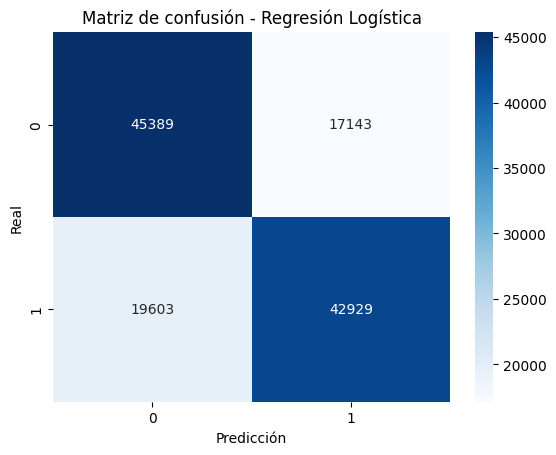

In [7]:
# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()


In [19]:
# Curva ROC para Regresión Logística
y_proba_rl = y_proba
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_proba_rl, pos_label=1)
auc_rl = roc_auc_score(y_test, y_proba_rl)

**Vuelvo a entrenar el modelo con las diez variables más explicativas para usar en el programa para predecir diabetes sí o no según los valores de estos 10 parámetros.**

In [23]:
features = ['_RFHLTH','_AGE_G','_BMI5CAT','_RACEG21','WTCHSALT',
            'ASBIRDUC','CTELNUM1','CTELENUM','SCNTMEL1']

X = df[features]
y = df['DIABETE3']

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

cat_cols = ['_RFHLTH','_AGE_G','_BMI5CAT','_RACEG21','WTCHSALT',
            'ASBIRDUC','CTELNUM1','CTELENUM','SCNTMEL1']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

modelo_rl = Pipeline(steps=[
    ('preproc', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

modelo_rl.fit(X, y)

joblib.dump(modelo_rl, "modelo_rl.pkl")
joblib.dump(features, "columnas_rl.pkl")


['columnas_rl.pkl']

In [21]:
joblib.load("columnas_rl.pkl")


['_RFHLTH',
 '_AGE_G',
 '_BMI5CAT',
 '_RACEG21',
 'WTCHSALT',
 'WTKG3',
 'ASBIRDUC',
 'CTELNUM1',
 'CTELENUM',
 'SCNTMEL1']

In [20]:
modelo_rl.predict(X_test).mean()


0.5259946907183523

In [22]:
df.groupby('DIABETE3')['WTKG3'].mean()


DIABETE3
0.0   -0.074242
1.0    0.472047
Name: WTKG3, dtype: float64

## SHAP

Przybyla-Kasperek, M. (2021). Machine learning for time series forecasting with Python. Packt Publishing. Recuperado de https://learning.oreilly.com/library/view/machine-learning-for/9781839217715/Text/Chapter_12.xhtml [Código adaptado]

- Para regresión logística, SHAP es equivalente a:
SHAPj=(xj−xˉj)⋅βj

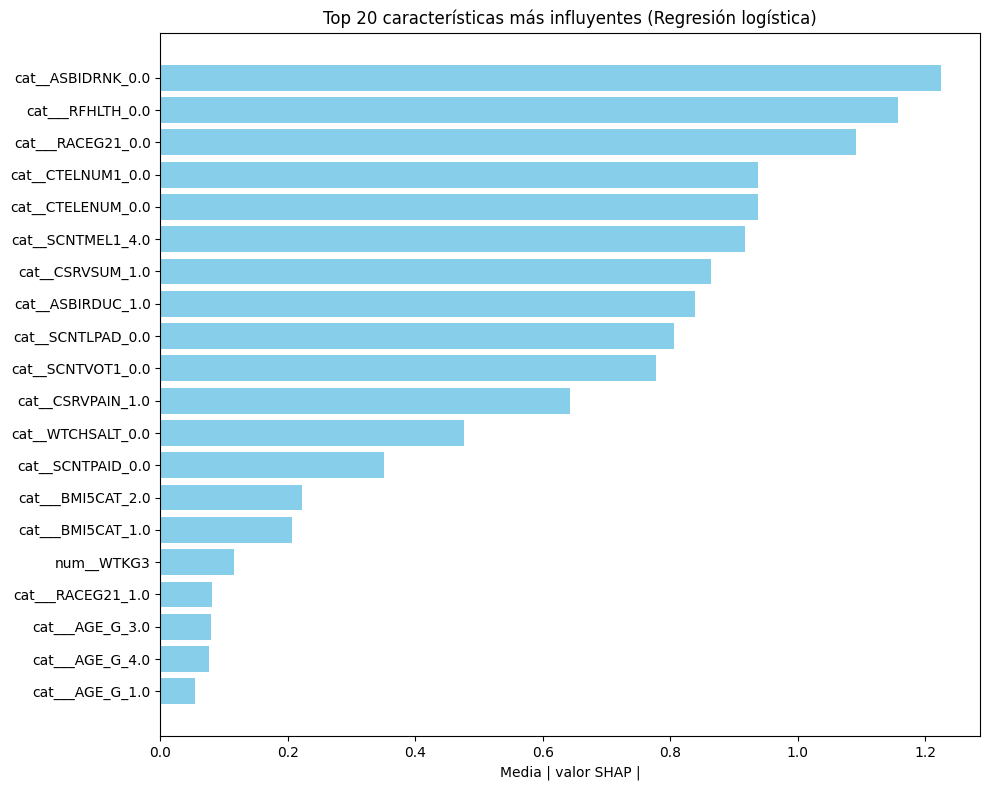

In [8]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import joblib

# -----------------------------
# 1. Cargar dataset balanceado
# -----------------------------
DATA_PATH = "train_aif360_reweighing.csv"
FEATURES = ['_STSTR','CTELENUM','WTKG3','ASBIDRNK','ASBIRDUC','WTCHSALT','CSRVSUM','CSRVPAIN',
   'SCNTMEL1','SCNTPAID','SCNTLPAD','SCNTVOT1','CTELNUM1','_RFHLTH','_RACEG21','_AGE_G','_BMI5CAT']
TARGET = "DIABETE3"

df = pd.read_csv(DATA_PATH)
X = df[FEATURES]
y = df[TARGET].astype(int)

# -----------------------------
# 2. Cargar pipeline y modelo
# -----------------------------
pipeline = joblib.load("modelo_rl.pkl")
modelo_final = pipeline.named_steps["clf"]

# -----------------------------
# 3. Transformar X con preprocesador
# -----------------------------
X_trans = pipeline.named_steps["preproc"].transform(X[FEATURES])
X_trans = sparse.csr_matrix(X_trans)  # asegurar formato disperso

# -----------------------------
# 4. Calcular SHAP manual en paralelo
# -----------------------------
coef = modelo_final.coef_[0]
mean = np.asarray(X_trans.mean(axis=0)).ravel()

def shap_col(j):
    col = X_trans[:, j]
    return np.abs(col.multiply(coef[j]) - col.multiply(mean[j])).mean()

mean_shap = Parallel(n_jobs=12)(
    delayed(shap_col)(j) for j in range(X_trans.shape[1])
)

mean_shap = np.array(mean_shap)

# -----------------------------
# 5. Crear DataFrame ordenado
# -----------------------------
feature_names = pipeline.named_steps["preproc"].get_feature_names_out()
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP value|": mean_shap
}).sort_values(by="Mean |SHAP value|")

# -----------------------------
# 6. Gráfica limpia (Top 20)
# -----------------------------
top_n = 20
shap_df_top = shap_df.tail(top_n)

plt.figure(figsize=(10, 8))
plt.barh(shap_df_top["Feature"], shap_df_top["Mean |SHAP value|"], color="skyblue")
plt.xlabel("Media | valor SHAP |")
plt.title(f"Top {top_n} características más influyentes (Regresión logística)")
plt.tight_layout()
plt.show()
